In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from xgboost import XGBClassifier

In [2]:
df = pd.read_csv('Train.csv', encoding='latin1')
df.head()

,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,morning,0-20,Afghanistan,38928346,652860.0,60
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,noon,21-30,Albania,2877797,27400.0,105
2,088c60f138,my boss is bullying me...,bullying me,negative,night,31-45,Algeria,43851044,2381740.0,18
3,9642c003ef,what interview! leave me alone,leave me alone,negative,morning,46-60,Andorra,77265,470.0,164
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,noon,60-70,Angola,32866272,1246700.0,26


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   textID            27481 non-null  str    
 1   text              27480 non-null  str    
 2   selected_text     27480 non-null  str    
 3   sentiment         27481 non-null  str    
 4   Time of Tweet     27481 non-null  str    
 5   Age of User       27481 non-null  str    
 6   Country           27481 non-null  str    
 7   Population -2020  27481 non-null  int64  
 8   Land Area (Km²)   27481 non-null  float64
 9   Density (P/Km²)   27481 non-null  int64  
dtypes: float64(1), int64(2), str(7)
memory usage: 5.8 MB


## Data Preparation

In [4]:
df.drop(['textID', 'selected_text', 'Time of Tweet',
         'Age of User', 'Country', 'Population -2020',
         'Land Area (Km\u00b2)', 'Density (P/Km\u00b2)'], axis=1, inplace=True)

df.dropna(inplace=True)

# Remove neutral class for binary classification
df = df[df['sentiment'] != 'neutral']

print(f"Dataset shape: {df.shape}")
print(f"\nClass distribution:")
print(df['sentiment'].value_counts())

Dataset shape: (16363, 2)

Class distribution:
sentiment
positive    8582
negative    7781
Name: count, dtype: int64


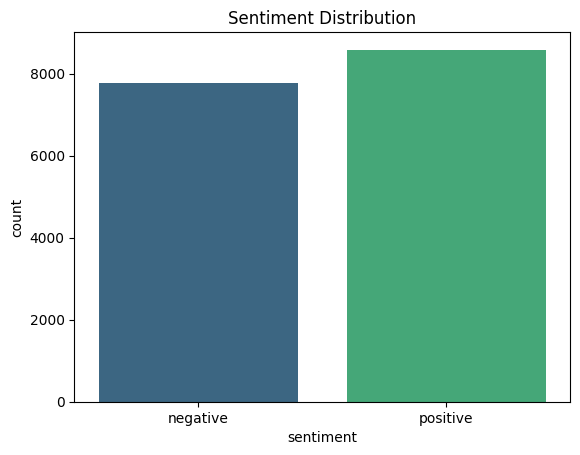

In [5]:
sns.countplot(data=df, x='sentiment', hue='sentiment', palette='viridis')
plt.title('Sentiment Distribution')
plt.show()

## Improved Text Preprocessing

In [6]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to C:\Users\Mouzan
[nltk_data]     Raza\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Mouzan
[nltk_data]     Raza\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Mouzan
[nltk_data]     Raza\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\Mouzan
[nltk_data]     Raza\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [7]:
# Custom stopword list that PRESERVES sentiment-bearing words
sentiment_words_to_keep = {
    'not', 'no', 'nor', 'neither', 'never', 'none', 'nobody', 'nothing',
    'nowhere', 'hardly', 'barely', 'scarcely', 'dont', "don't",
    'doesnt', "doesn't", 'didnt', "didn't", 'wasnt', "wasn't",
    'isnt', "isnt", 'arent', "aren't", 'wont', "won't",
    'wouldnt', "wouldn't", 'couldnt', "couldn't", 'shouldnt', "shouldn't",
    'very', 'really', 'extremely', 'too', 'most', 'more', 'much',
    'but', 'however', 'although', 'though', 'yet', 'still',
    'just', 'only', 'even', 'already', 'yet', 'again',
    'against', 'between', 'through', 'during', 'before', 'after',
    'above', 'below', 'up', 'down', 'out', 'off', 'over', 'under',
    'few', 'own', 'same', 'than', 'so', 'why', 'what', 'which',
    'who', 'whom', 'this', 'that', 'these', 'those'
}

default_stopwords = set(stopwords.words('english'))
custom_stopwords = default_stopwords - sentiment_words_to_keep

print(f"Original stopwords: {len(default_stopwords)}")
print(f"Custom stopwords (after removing sentiment words): {len(custom_stopwords)}")
print(f"\nWords preserved for sentiment: {sentiment_words_to_keep}")

Original stopwords: 198
Custom stopwords (after removing sentiment words): 150

Words preserved for sentiment: {'nor', 'still', 'over', 'really', "aren't", 'wont', 'arent', 'too', 'not', 'but', 'none', "wasn't", 'own', 'extremely', 'above', 'more', 'shouldnt', 'what', 'nowhere', 'wouldnt', "doesn't", 'nobody', 'this', 'below', 'whom', 'up', "won't", 'even', 'under', 'which', 'wasnt', 'against', 'hardly', "don't", 'during', 'only', 'before', 'down', 'out', 'again', 'very', 'nothing', 'who', 'never', "wouldn't", 'few', 'after', "shouldn't", 'scarcely', 'same', 'dont', 'neither', "didn't", 'though', 'through', 'off', 'although', "couldn't", 'however', 'already', 'between', 'isnt', 'than', 'so', 'those', 'most', 'much', 'couldnt', 'yet', 'why', 'doesnt', 'these', 'didnt', 'barely', 'just', 'that', 'no'}


In [8]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Keep only letters
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def preprocess_text(text):
    tokens = word_tokenize(text)
    tokens = [token for token in tokens if token not in custom_stopwords and len(token) > 2]
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    return ' '.join(tokens)

In [9]:
df['text'] = df['text'].apply(clean_text)
df['text'] = df['text'].apply(preprocess_text)

In [10]:
le = LabelEncoder()
df['sentiment'] = le.fit_transform(df['sentiment'])

In [11]:
X = df['text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [13]:
def evaluate_model(model, X_train, y_train, X_test, y_test, name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name}: {acc:.4f}")
    return acc

In [14]:
models = [
    ("LogisticRegression", LogisticRegression(max_iter=1000, C=1.0)),
    ("RandomForest", RandomForestClassifier(n_estimators=200, random_state=42)),
    ("DecisionTree", DecisionTreeClassifier(random_state=42)),
    ("SVC", SVC(kernel='linear', C=1.0)),
    ("MultinomialNB", MultinomialNB(alpha=0.1))
]

In [15]:
results = {}
for name, model in models:
    results[name] = evaluate_model(model, X_train_tfidf, y_train, X_test_tfidf, y_test, name)

LogisticRegression: 0.8821
RandomForest: 0.8753
DecisionTree: 0.8372
SVC: 0.8796
MultinomialNB: 0.8430


In [18]:
final_model=LogisticRegression(max_iter=1000, C=1.0)

In [20]:
final_model.fit(X_train_tfidf,y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [22]:
y_pred=final_model.predict(X_test_tfidf)

In [23]:
accuracy_score(y_pred,y_test)

0.8820653834402689